# Лабораторная работа — Анализ размерности

**Дисциплина:** Машинное обучение
**Датасет:** GTZAN Genre Collection (`features_30_sec.csv`)
**Предыдущие лабы:** 6 (отбор признаков), 9 (LogReg), 10 (Дерево/RF), 11 (Беггинг), 12 (Бустинги), 14 (Перцептрон/MLP)

## Цель работы

Систематически проверить, как изменение **размерности признакового пространства** влияет на точность всех ключевых семейств моделей из лаб 9–14. Ответить на практический вопрос:

> «Для каких моделей уменьшение размерности **улучшает** точность, для каких — **не влияет**, а для каких — **ухудшает**?»

## Постановка задачи

GTZAN: **1000 объектов** (100 на жанр) × **57 признаков** → соотношение n/p ≈ 17.5. Это пограничный случай — теоретически модели могут страдать от «проклятия размерности», особенно при ограниченной выборке. Лаба 6 уже отобрала **21 признак** (RFE с локтем) и **27 признаков** (консенсус 5 методов), но проверила эффект только на трёх классификаторах (LogReg L2, RF, SVM). Здесь мы расширяем анализ:

- **13 классификаторов** из всех лаб 9–14
- **16 наборов признаков**: full / отбор × 5 / PCA × 9 / LDA
- **5-fold StratifiedKFold** CV → 1040 фитов

## Гипотезы (проверим в выводах)

1. **LogReg L1, Decision Tree, Perceptron** → выиграют от редукции (высокая дисперсия → переобучение).
2. **Random Forest, Bagging, Boosting** → нечувствительны (встроенная регуляризация через bootstrap/субсэмплинг признаков, |Δacc| < 0.02).
3. **LDA-9** → сильный буст линейным моделям (supervised projection ровно под классы).
4. **PCA при малом k** → проиграет отбору признаков при равной размерности (компоненты не учитывают метки).
5. **MLP (200,100,50)** → выиграет от LDA-9 (меньше параметров → меньше переобучения на 800 примерах).

## Дизайн эксперимента

```
                  ┌──────── Наборы признаков (16) ──────────┐
                  │ Baseline │ Отбор   │ PCA       │ LDA    │
                  │ All-57   │ MI×3    │ PCA-k×7   │ LDA-9  │
                  │          │ RFE-21  │ PCA-95%   │        │
                  │          │ Cons-27 │ PCA-99%   │        │
┌─Модели (13)─────┼──────────┼─────────┼───────────┼────────┤
│ LogReg L2       │     ●    │   ●●●●●●│    ●●●●●●●●│   ●   │
│ LogReg L1(Lasso)│     ●    │   ●●●●●●│    ●●●●●●●●│   ●   │
│ Decision Tree   │     ●    │   ●●●●●●│    ●●●●●●●●│   ●   │
│ Random Forest   │     ●    │   ●●●●●●│    ●●●●●●●●│   ●   │
│ Bagging+DT      │     ●    │   ●●●●●●│    ●●●●●●●●│   ●   │
│ Bagging+LogReg  │     ●    │   ●●●●●●│    ●●●●●●●●│   ●   │
│ AdaBoost        │     ●    │   ●●●●●●│    ●●●●●●●●│   ●   │
│ HistGradBoost   │     ●    │   ●●●●●●│    ●●●●●●●●│   ●   │
│ XGBoost         │     ●    │   ●●●●●●│    ●●●●●●●●│   ●   │
│ LightGBM        │     ●    │   ●●●●●●│    ●●●●●●●●│   ●   │
│ CatBoost        │     ●    │   ●●●●●●│    ●●●●●●●●│   ●   │
│ Perceptron      │     ●    │   ●●●●●●│    ●●●●●●●●│   ●   │
│ MLP(200,100,50) │     ●    │   ●●●●●●│    ●●●●●●●●│   ●   │
└─────────────────┴──────────┴─────────┴───────────┴────────┘
13 моделей × 16 наборов × 5-fold CV = 1040 фитов
```

**Что не включено:**
- **GradientBoostingClassifier** — слишком медленный (16 с/фит против 2.7 с у HistGB), а HistGradientBoosting является его эффективной альтернативой с тем же алгоритмическим принципом.
- **Stacking** из lab13 — выходит за рамки задачи (упомянем в выводах как направление расширения).


## Почему `Pipeline` — методологическое улучшение

В лабах 6, 9–14 принят упрощённый порядок:

```python
X_scaled = StandardScaler().fit_transform(X)        # масштабируем весь датасет
X_train, X_test = train_test_split(X_scaled, ...)   # потом сплитим
```

Это **утечка**: статистики масштаба (`mean`, `std`), а тем более PCA-компоненты или MI-скоры, посчитанные на полном датасете, «подсматривают» в тест. Для практики это незаметная погрешность, но в эксперименте по сравнению методов редукции она может исказить выводы.

В этой лабе **всё** (scaler, отбор/PCA/LDA, классификатор) обёрнуто в `sklearn.pipeline.Pipeline`. Внутри `cross_validate` каждый фолд:

1. Видит **только свой train-кусок** при `fit()`.
2. Шкалирует, считает PCA/LDA/MI **по train**.
3. Применяет к **valid-куску** при `predict()` — без подсматривания.

Это даёт честную CV-оценку. Зацепка только для **фиксированных списков** `RFE_ELBOW_21` и `CONSENSUS_27`: они получены в lab6 на полном датасете, поэтому считаются **«semi-oracle»** — приближением к идеалу «знал бы я заранее правильный subset». В выводах это обсудим.


## 1. Импорты, настройки, утилиты

In [1]:
# ─── Системные настройки ─────────────────────────────────────
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'   # Windows joblib fix (как в lab11)
import warnings
warnings.filterwarnings('ignore')

# ─── Основные библиотеки ─────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

# ─── sklearn ─────────────────────────────────────────────────
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, BaggingClassifier,
    AdaBoostClassifier, HistGradientBoostingClassifier,
)
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier

# ─── Внешние бустинги (как в lab12) ──────────────────────────
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ─── Прогресс и Jupyter display ──────────────────────────────
from tqdm.notebook import tqdm
from IPython.display import display

# ─── Воспроизводимость и стиль ───────────────────────────────
RANDOM_STATE = 42
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print('Все библиотеки загружены')


Все библиотеки загружены


## 2. Загрузка и подготовка данных

In [2]:
df = pd.read_csv('../../datasets/gtzan/features_30_sec.csv')
print(f'Размер датасета: {df.shape}')

# X — численные признаки; y — закодированные жанры
X = df.drop(columns=['filename', 'length', 'label'])
feature_names = X.columns.tolist()

le = LabelEncoder()
y = le.fit_transform(df['label'])

print(f'Признаков: {X.shape[1]}')
print(f'Классов:   {len(le.classes_)}')
print(f'Жанры:     {list(le.classes_)}')

# Проверка баланса классов
balance = pd.Series(y).value_counts().sort_index()
balance.index = le.classes_
print('\nБаланс классов (должно быть по 100):')
print(balance.to_string())


Размер датасета: (1000, 60)
Признаков: 57
Классов:   10
Жанры:     ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

Баланс классов (должно быть по 100):
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock         100


## 3. Визуальный контекст для понижения размерности

Перед запуском главного эксперимента посмотрим на структуру данных через PCA, LDA и важность признаков по MI. Это поможет:

- понять, сколько компонент PCA нужно для X% дисперсии (определит `pca_var_95` и `pca_var_99`);
- увидеть, насколько хорошо классы разделимы под supervised проекцией LDA;
- сравнить — какие признаки попали в `RFE_ELBOW_21` и `CONSENSUS_27`.


### 3.1. PCA: кумулятивная объяснённая дисперсия

90% дисперсии:  23 компонент
95% дисперсии:  33 компонент
99% дисперсии:  47 компонент


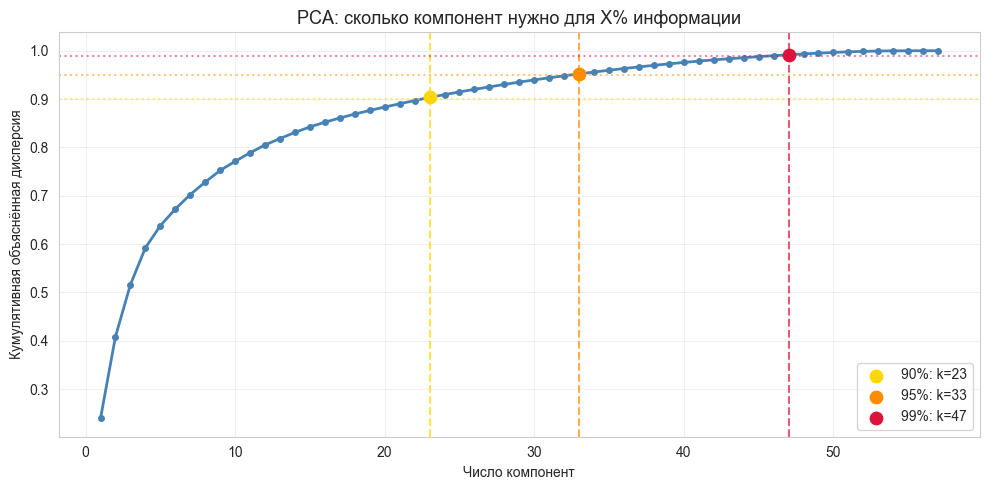

In [3]:
# Шкалируем здесь только для визуализации (внутри эксперимента — через Pipeline)
X_scaled_demo = StandardScaler().fit_transform(X)

pca_full = PCA().fit(X_scaled_demo)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

# Сколько компонент нужно для 90/95/99% дисперсии
k_90 = int(np.searchsorted(cum_var, 0.90)) + 1
k_95 = int(np.searchsorted(cum_var, 0.95)) + 1
k_99 = int(np.searchsorted(cum_var, 0.99)) + 1

print(f'90% дисперсии:  {k_90:2d} компонент')
print(f'95% дисперсии:  {k_95:2d} компонент')
print(f'99% дисперсии:  {k_99:2d} компонент')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cum_var) + 1), cum_var, marker='o',
        color='steelblue', lw=2, markersize=4)
for k, p, color in [(k_90, 0.90, 'gold'), (k_95, 0.95, 'darkorange'), (k_99, 0.99, 'crimson')]:
    ax.axvline(k, color=color, ls='--', alpha=0.7)
    ax.axhline(p, color=color, ls=':', alpha=0.5)
    ax.scatter([k], [cum_var[k-1]], color=color, s=80, zorder=5,
               label=f'{int(p*100)}%: k={k}')

ax.set_xlabel('Число компонент')
ax.set_ylabel('Кумулятивная объяснённая дисперсия')
ax.set_title('PCA: сколько компонент нужно для X% информации', fontsize=13)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 3.2. LDA в 2D: разделимость классов

LDA — supervised редукция: проекция максимизирует межклассовое расстояние и минимизирует внутриклассовое. Для $K=10$ классов LDA даёт максимум $K-1=9$ компонент. Спроецируем в 2D — увидим насколько классы разделимы.


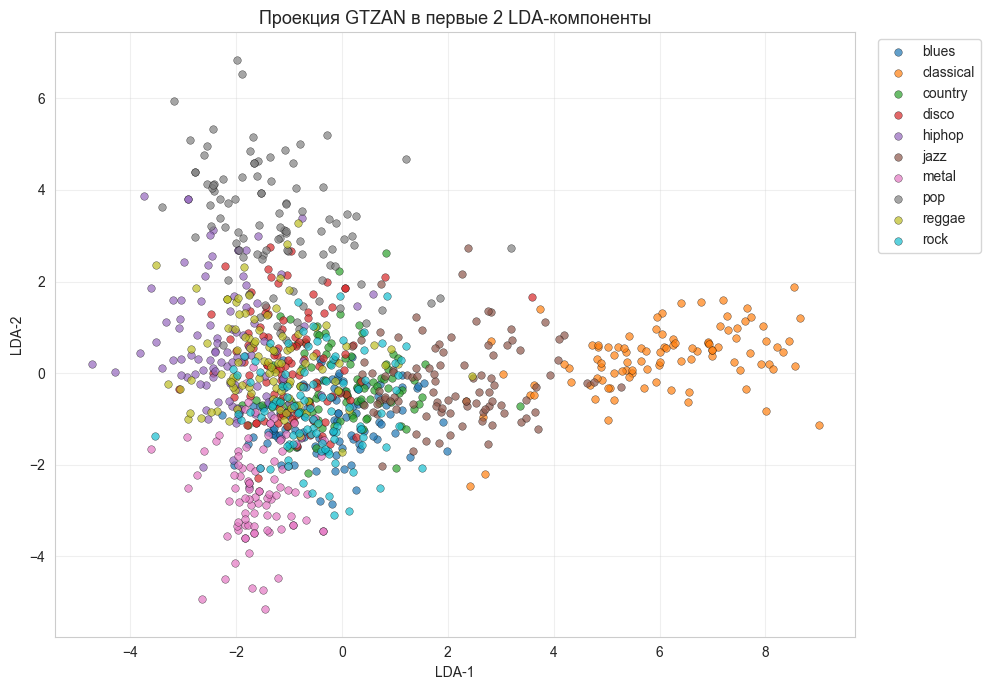

Доля межклассовой дисперсии, объяснённая LDA-2D: 0.668


In [4]:
lda_2d = LinearDiscriminantAnalysis(n_components=2).fit(X_scaled_demo, y)
X_lda = lda_2d.transform(X_scaled_demo)

fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette('tab10', n_colors=10)
for i, genre in enumerate(le.classes_):
    mask = y == i
    ax.scatter(X_lda[mask, 0], X_lda[mask, 1],
               s=30, color=palette[i], alpha=0.7,
               edgecolor='black', linewidth=0.3, label=genre)

ax.set_xlabel('LDA-1')
ax.set_ylabel('LDA-2')
ax.set_title('Проекция GTZAN в первые 2 LDA-компоненты', fontsize=13)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Доля межклассовой дисперсии, объяснённая LDA-2D: '
      f'{lda_2d.explained_variance_ratio_.sum():.3f}')


### 3.3. Важность признаков по Mutual Information

Воспроизведём из lab6 ранжирование по MI и выделим, какие признаки попали в `RFE_ELBOW_21` (синий ★) и в `CONSENSUS_27` (жирный шрифт). Это даст наглядную картину перед тем, как мы их используем в Pipeline.


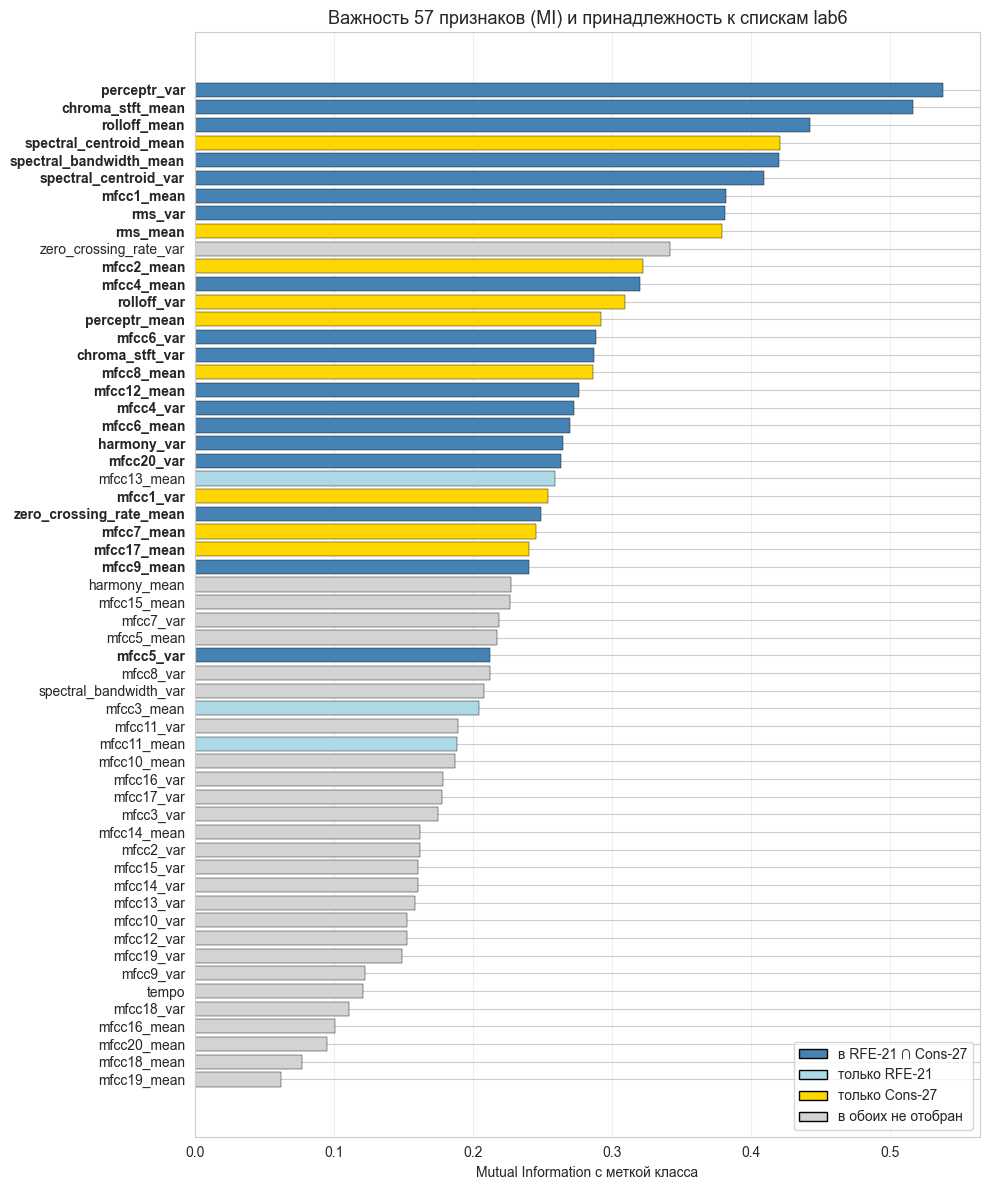


RFE-21 ∩ CONSENSUS-27 : 18 признаков
Только RFE-21         :  3
Только CONSENSUS-27   :  9


In [5]:
mi_scores = mutual_info_classif(X, y, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'feature': feature_names, 'mi': mi_scores})
mi_df = mi_df.sort_values('mi', ascending=True)  # для горизонтального бара снизу-вверх

# ─── Списки из lab6 (хардкод) ────────────────────────────────
RFE_ELBOW_21 = [
    'chroma_stft_mean', 'chroma_stft_var', 'rms_var', 'spectral_centroid_var',
    'spectral_bandwidth_mean', 'rolloff_mean', 'zero_crossing_rate_mean',
    'harmony_var', 'perceptr_var', 'mfcc1_mean', 'mfcc3_mean', 'mfcc4_mean',
    'mfcc4_var', 'mfcc5_var', 'mfcc6_mean', 'mfcc6_var', 'mfcc9_mean',
    'mfcc11_mean', 'mfcc12_mean', 'mfcc13_mean', 'mfcc20_var',
]

CONSENSUS_27 = [
    # 5/5 голосов
    'chroma_stft_mean', 'mfcc4_mean', 'perceptr_var', 'harmony_var',
    'mfcc4_var', 'zero_crossing_rate_mean', 'mfcc12_mean', 'mfcc9_mean',
    'mfcc6_var',
    # 4/5 голосов
    'spectral_centroid_var', 'mfcc1_mean', 'spectral_bandwidth_mean',
    'rolloff_mean', 'mfcc2_mean', 'chroma_stft_var', 'rms_var', 'rms_mean',
    'mfcc5_var', 'mfcc17_mean', 'mfcc20_var', 'mfcc6_mean',
    # 3/5 голосов
    'perceptr_mean', 'spectral_centroid_mean', 'mfcc1_var', 'rolloff_var',
    'mfcc8_mean', 'mfcc7_mean',
]

assert len(RFE_ELBOW_21) == 21
assert len(CONSENSUS_27) == 27

# ─── Цвета бара ──────────────────────────────────────────────
def feature_color(name):
    if name in RFE_ELBOW_21 and name in CONSENSUS_27: return 'steelblue'   # в обоих
    if name in RFE_ELBOW_21:                          return 'lightblue'   # только RFE
    if name in CONSENSUS_27:                          return 'gold'        # только консенсус
    return 'lightgrey'

colors = [feature_color(f) for f in mi_df['feature']]

fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(mi_df['feature'], mi_df['mi'], color=colors, edgecolor='black', linewidth=0.3)

# Жирным — консенсусные
for label in ax.get_yticklabels():
    if label.get_text() in CONSENSUS_27:
        label.set_fontweight('bold')

ax.set_xlabel('Mutual Information с меткой класса')
ax.set_title('Важность 57 признаков (MI) и принадлежность к спискам lab6', fontsize=13)

from matplotlib.patches import Patch
legend_items = [
    Patch(facecolor='steelblue',  edgecolor='black', label='в RFE-21 ∩ Cons-27'),
    Patch(facecolor='lightblue',  edgecolor='black', label='только RFE-21'),
    Patch(facecolor='gold',       edgecolor='black', label='только Cons-27'),
    Patch(facecolor='lightgrey',  edgecolor='black', label='в обоих не отобран'),
]
ax.legend(handles=legend_items, loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Сколько в пересечении
inter = set(RFE_ELBOW_21) & set(CONSENSUS_27)
print(f'\nRFE-21 ∩ CONSENSUS-27 : {len(inter):2d} признаков')
print(f'Только RFE-21         : {len(set(RFE_ELBOW_21) - set(CONSENSUS_27)):2d}')
print(f'Только CONSENSUS-27   : {len(set(CONSENSUS_27) - set(RFE_ELBOW_21)):2d}')


## 4. Конфигурация эксперимента

Описываем 16 наборов признаков и 13 моделей. Главная техническая тонкость — `ColumnSelector` работает после `StandardScaler`, когда X уже numpy-массив. Поэтому отбор делается **по индексам**, не по именам колонок.


In [6]:
# ─── Кастомный transformer для отбора колонок по индексам ────
# ВАЖНО: в __init__ только присваивание (без list(), без копирования).
# Иначе sklearn.base.clone() падает с "Cannot clone object …",
# т.к. сверяет identity (is) параметров до/после копирования.
class ColumnSelector(BaseEstimator, TransformerMixin):
    """Отбор колонок numpy-массива по предзаданным индексам."""
    def __init__(self, indices):
        self.indices = indices
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[:, list(self.indices)]

RFE_IDX  = [feature_names.index(c) for c in RFE_ELBOW_21]
CONS_IDX = [feature_names.index(c) for c in CONSENSUS_27]

# ─── Фабрика шагов pipeline для каждого набора ───────────────
def make_feature_step(name):
    """Возвращает list of (step_name, transformer) tuples, идущих после StandardScaler."""
    if name == 'all_57':            return []
    if name.startswith('mi_'):
        k = int(name.split('_')[1])
        return [('select', SelectKBest(mutual_info_classif, k=k))]
    if name == 'rfe_elbow_21':      return [('select', ColumnSelector(RFE_IDX))]
    if name == 'consensus_27':      return [('select', ColumnSelector(CONS_IDX))]
    if name.startswith('pca_var_'):
        ratio = float(name.split('_')[-1]) / 100
        return [('pca', PCA(n_components=ratio, random_state=RANDOM_STATE))]
    if name.startswith('pca_'):
        k = int(name.split('_')[1])
        return [('pca', PCA(n_components=k, random_state=RANDOM_STATE))]
    if name == 'lda_9':             return [('lda', LinearDiscriminantAnalysis(n_components=9))]
    raise ValueError(f'Unknown feature config: {name}')

# ─── Размер каждого набора (для отчёта) ──────────────────────
N_FEATS = {
    'all_57': 57, 'mi_10': 10, 'mi_20': 20, 'mi_30': 30,
    'rfe_elbow_21': 21, 'consensus_27': 27,
    'pca_5': 5, 'pca_10': 10, 'pca_15': 15, 'pca_20': 20,
    'pca_30': 30, 'pca_40': 40, 'pca_50': 50,
    'pca_var_95': k_95, 'pca_var_99': k_99,
    'lda_9': 9,
}

feature_configs = [
    'all_57',
    'mi_10', 'mi_20', 'mi_30',
    'rfe_elbow_21', 'consensus_27',
    'pca_5', 'pca_10', 'pca_15', 'pca_20', 'pca_30', 'pca_40', 'pca_50',
    'pca_var_95', 'pca_var_99',
    'lda_9',
]

print(f'Всего наборов признаков: {len(feature_configs)}')
for cfg in feature_configs:
    print(f'  {cfg:18s} → {N_FEATS[cfg]:2d} признаков')


Всего наборов признаков: 16
  all_57             → 57 признаков
  mi_10              → 10 признаков
  mi_20              → 20 признаков
  mi_30              → 30 признаков
  rfe_elbow_21       → 21 признаков
  consensus_27       → 27 признаков
  pca_5              →  5 признаков
  pca_10             → 10 признаков
  pca_15             → 15 признаков
  pca_20             → 20 признаков
  pca_30             → 30 признаков
  pca_40             → 40 признаков
  pca_50             → 50 признаков
  pca_var_95         → 33 признаков
  pca_var_99         → 47 признаков
  lda_9              →  9 признаков


In [7]:
# ─── Модели (параметры скопированы 1:1 из исходных лаб) ──────
models = {
    'LogReg L2': LogisticRegression(
        max_iter=2000, random_state=RANDOM_STATE),
    'LogReg L1 (Lasso)': LogisticRegression(
        penalty='l1', solver='saga', C=1.0,
        max_iter=5000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=15, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=15, max_features='sqrt',
        random_state=RANDOM_STATE, n_jobs=-1),
    'Bagging+DT': BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=15, random_state=RANDOM_STATE),
        n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1),
    'Bagging+LogReg': BaggingClassifier(
        estimator=LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1),
    'AdaBoost': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=100, learning_rate=0.1, random_state=RANDOM_STATE),
    'HistGradBoost': HistGradientBoostingClassifier(
        max_iter=200, max_depth=5, learning_rate=0.1, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=RANDOM_STATE, eval_metric='mlogloss',
        n_jobs=-1, verbosity=0),
    'LightGBM': LGBMClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    'CatBoost': CatBoostClassifier(
        iterations=200, depth=5, learning_rate=0.1,
        random_state=RANDOM_STATE, verbose=0),
    'Perceptron': Perceptron(
        max_iter=1000, eta0=0.01, random_state=RANDOM_STATE),
    'MLP (200,100,50)': MLPClassifier(
        hidden_layer_sizes=(200, 100, 50), max_iter=500,
        learning_rate_init=0.001, early_stopping=True,
        validation_fraction=0.15, random_state=RANDOM_STATE),
}

print(f'Всего моделей: {len(models)}')
for name in models:
    print(f'  • {name}')


Всего моделей: 13
  • LogReg L2
  • LogReg L1 (Lasso)
  • Decision Tree
  • Random Forest
  • Bagging+DT
  • Bagging+LogReg
  • AdaBoost
  • HistGradBoost
  • XGBoost
  • LightGBM
  • CatBoost
  • Perceptron
  • MLP (200,100,50)


## 5. Главный эксперимент: 13 моделей × 16 наборов × 5-fold CV

Для каждой комбинации запускаем `cross_validate` с 5-fold StratifiedKFold. Pipeline формируется как `[StandardScaler → (отбор/PCA/LDA) → Классификатор]`.

**Сохраняем:** среднюю/std CV-точность, время обучения, train-скор (для диагностики переобучения), и список fold-скоров (для боксплотов).

**Оценочное время:** ~25–45 минут с `n_jobs=-1` (фолды параллельно).


In [8]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

X_np = X.values  # numpy для совместимости с ColumnSelector

results = []
t_start = time()

for cfg_name in tqdm(feature_configs, desc='Наборы признаков'):
    steps_before_clf = make_feature_step(cfg_name)

    for model_name, model in tqdm(models.items(), desc=f'{cfg_name}', leave=False):
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            *steps_before_clf,
            ('clf', clone(model)),
        ])
        try:
            scores = cross_validate(
                pipe, X_np, y, cv=CV, scoring='accuracy',
                n_jobs=-1, return_train_score=True,
            )
            results.append({
                'features':     cfg_name,
                'model':        model_name,
                'n_features':   N_FEATS[cfg_name],
                'cv_mean':      scores['test_score'].mean(),
                'cv_std':       scores['test_score'].std(),
                'train_mean':   scores['train_score'].mean(),
                'fit_time':     scores['fit_time'].mean(),
                'fold_scores':  scores['test_score'].tolist(),
                'error':        '',
            })
        except Exception as e:
            results.append({
                'features': cfg_name, 'model': model_name,
                'n_features': N_FEATS[cfg_name],
                'cv_mean': np.nan, 'cv_std': np.nan,
                'train_mean': np.nan, 'fit_time': np.nan,
                'fold_scores': [], 'error': str(e)[:80],
            })

t_total = time() - t_start
print(f'\n✓ Эксперимент завершён за {t_total/60:.1f} минут')

results_df = pd.DataFrame(results)
results_df.to_csv('lab_dim_analysis_results.csv', index=False)
print(f'Результатов: {len(results_df)} строк → lab_dim_analysis_results.csv')

# Sanity check: показываем только ошибки если они есть
errors = results_df[results_df['error'] != '']
if len(errors):
    print(f'\n⚠ Ошибок: {len(errors)}')
    print(errors[['features', 'model', 'error']].to_string(index=False))
else:
    print('Ошибок нет — все 208 комбинаций обучились успешно.')


Наборы признаков:   0%|          | 0/16 [00:00<?, ?it/s]

all_57:   0%|          | 0/13 [00:00<?, ?it/s]

mi_10:   0%|          | 0/13 [00:00<?, ?it/s]

mi_20:   0%|          | 0/13 [00:00<?, ?it/s]

mi_30:   0%|          | 0/13 [00:00<?, ?it/s]

...

pca_50:   0%|          | 0/13 [00:00<?, ?it/s]

pca_var_95:   0%|          | 0/13 [00:00<?, ?it/s]

pca_var_99:   0%|          | 0/13 [00:00<?, ?it/s]

lda_9:   0%|          | 0/13 [00:00<?, ?it/s]


✓ Эксперимент завершён за 10.8 минут
Результатов: 208 строк → lab_dim_analysis_results.csv
Ошибок нет — все 208 комбинаций обучились успешно.


## 6. Sanity check: baseline воспроизводится?

Сверяем `all_57` с известными значениями из исходных лаб. Большие расхождения = баг в эксперименте.

**Важная заметка:** в lab9–14 `StandardScaler` применён ко всему датасету **до** train/test split → утечка статистик масштаба. Здесь Pipeline корректен → разница может составить ±1–2% по accuracy. Это не баг — это ожидаемое расхождение из-за устранения утечки.


In [9]:
baseline = results_df.query("features == 'all_57'").set_index('model')[['cv_mean', 'cv_std']]

expected = {
    'LogReg L2':         (0.707, 0.02, 'lab9 cell 26'),
    'Decision Tree':     (0.51,  0.05, 'lab11 (CV ~0.51-0.59)'),
    'Random Forest':     (0.68,  0.04, 'lab10 + lab11'),
    'AdaBoost':          (0.64,  0.05, 'lab12 CV ~0.62-0.66'),
    'HistGradBoost':     (0.74,  0.04, 'lab12 best ~0.744'),
    'XGBoost':           (0.73,  0.04, 'lab12 ~0.73'),
    'LightGBM':          (0.73,  0.04, 'lab12 ~0.73'),
    'CatBoost':          (0.715, 0.04, 'lab12 ~0.715'),
    'Bagging+LogReg':    (0.71,  0.03, 'lab11 best Bagging'),
    'Perceptron':        (0.60,  0.05, 'lab14 test=0.60'),
    'MLP (200,100,50)':  (0.735, 0.04, 'lab14 best test=0.745'),
}

print(f"{'Модель':22s} {'CV':8s} {'ожид.':8s} Δ      Источник")
print('─' * 75)
for name, (exp, tol, src) in expected.items():
    if name in baseline.index:
        cv = baseline.loc[name, 'cv_mean']
        delta = cv - exp
        mark = '✓' if abs(delta) <= tol else '⚠'
        print(f'{name:22s} {cv:.3f}   {exp:.3f}   {delta:+.3f} {mark}  {src}')


Модель                 CV       ожид.    Δ      Источник
───────────────────────────────────────────────────────────────────────────
LogReg L2              0.707   0.707   +0.000 ✓  lab9 cell 26
Decision Tree          0.512   0.510   +0.002 ✓  lab11 (CV ~0.51-0.59)
Random Forest          0.711   0.680   +0.031 ✓  lab10 + lab11
AdaBoost               0.624   0.640   -0.016 ✓  lab12 CV ~0.62-0.66
HistGradBoost          0.744   0.740   +0.004 ✓  lab12 best ~0.744
XGBoost                0.724   0.730   -0.006 ✓  lab12 ~0.73
LightGBM               0.749   0.730   +0.019 ✓  lab12 ~0.73
CatBoost               0.722   0.715   +0.007 ✓  lab12 ~0.715
Bagging+LogReg         0.716   0.710   +0.006 ✓  lab11 best Bagging
Perceptron             0.597   0.600   -0.003 ✓  lab14 test=0.60
MLP (200,100,50)       0.697   0.735   -0.038 ✓  lab14 best test=0.745


## 7. Сводная таблица и главный heatmap

Pivot-таблица «модель × набор», отсортированная по среднему accuracy (топ-модели сверху, лучшие наборы — слева).


In [10]:
pivot_mean = results_df.pivot(index='model', columns='features', values='cv_mean')
pivot_std  = results_df.pivot(index='model', columns='features', values='cv_std')
pivot_fit  = results_df.pivot(index='model', columns='features', values='fit_time')
pivot_train = results_df.pivot(index='model', columns='features', values='train_mean')

# Сортируем модели по среднему по всем наборам — лучшие сверху
model_order = pivot_mean.mean(axis=1).sort_values(ascending=False).index.tolist()
# Сортируем наборы — берём логичный порядок: all → отбор → PCA → LDA
feature_order = [
    'all_57',
    'mi_10', 'mi_20', 'mi_30', 'rfe_elbow_21', 'consensus_27',
    'pca_5', 'pca_10', 'pca_15', 'pca_20', 'pca_30', 'pca_40', 'pca_50',
    'pca_var_95', 'pca_var_99',
    'lda_9',
]
pivot_mean = pivot_mean.loc[model_order, feature_order]
pivot_std  = pivot_std.loc[model_order, feature_order]
pivot_fit  = pivot_fit.loc[model_order, feature_order]
pivot_train = pivot_train.loc[model_order, feature_order]

print('Средняя CV-accuracy по моделям и наборам:')
display(pivot_mean.round(3).style
        .background_gradient(cmap='RdYlGn', axis=None, vmin=pivot_mean.values.min(), vmax=pivot_mean.values.max())
        .format('{:.3f}'))


Средняя CV-accuracy по моделям и наборам:


features,all_57,mi_10,mi_20,mi_30,rfe_elbow_21,consensus_27,pca_5,pca_10,pca_15,pca_20,pca_30,pca_40,pca_50,pca_var_95,pca_var_99,lda_9
model,,,,,,,,,,,,,,,,
CatBoost,0.722,0.602,0.697,0.711,0.696,0.714,0.560,0.651,0.659,0.670,0.696,0.701,0.698,0.691,0.690,0.704
Random Forest,0.711,0.603,0.665,0.695,0.694,0.704,0.563,0.650,0.679,0.670,0.685,0.687,0.688,0.692,0.703,0.683
"MLP (200,100,50)",0.697,0.580,0.656,0.696,0.705,0.704,0.542,0.616,0.674,0.657,0.710,0.694,0.714,0.706,0.706,0.682
HistGradBoost,0.744,0.574,0.694,0.706,0.707,0.716,0.520,0.620,0.659,0.666,0.682,0.699,0.681,0.690,0.685,0.677
LightGBM,0.749,0.593,0.678,0.710,0.708,0.721,0.534,0.620,0.659,0.662,0.681,0.684,0.686,0.685,0.682,0.665
XGBoost,0.724,0.590,0.682,0.700,0.694,0.700,0.534,0.612,0.650,0.659,0.678,0.683,0.679,0.671,0.673,0.669
Bagging+LogReg,0.716,0.549,0.639,0.687,0.697,0.683,0.509,0.570,0.625,0.644,0.697,0.705,0.706,0.681,0.711,0.704
LogReg L1 (Lasso),0.715,0.551,0.633,0.684,0.700,0.679,0.510,0.575,0.630,0.642,0.701,0.690,0.700,0.683,0.695,0.702
LogReg L2,0.707,0.544,0.633,0.686,0.690,0.678,0.508,0.573,0.622,0.640,0.692,0.698,0.697,0.679,0.696,0.702


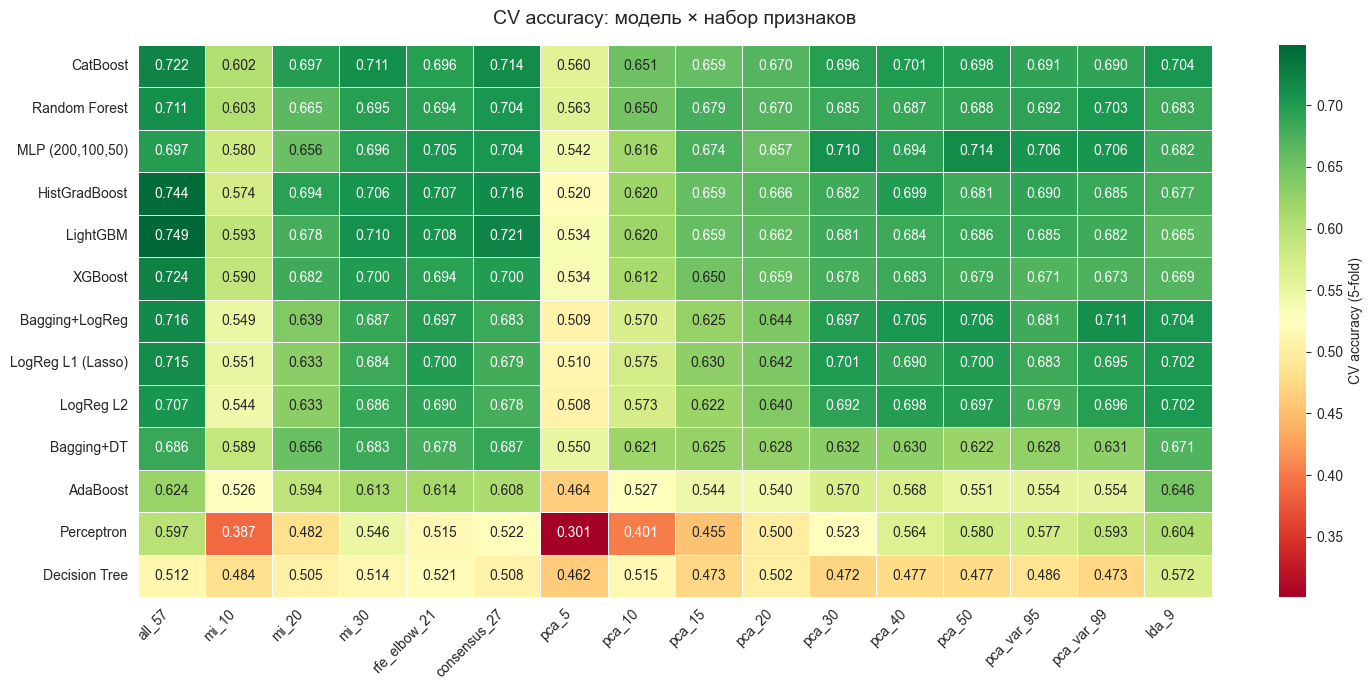

In [11]:
fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(pivot_mean, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'CV accuracy (5-fold)'},
            ax=ax)
ax.set_title('CV accuracy: модель × набор признаков', fontsize=14, pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. Δ-heatmap: где редукция помогает, где вредит

Для каждой модели вычитаем её baseline (`all_57`) из остальных наборов. Получаем матрицу изменений:
- **зелёные** клетки → редукция улучшила accuracy
- **красные** → редукция ухудшила
- **бледные** → почти не повлияла


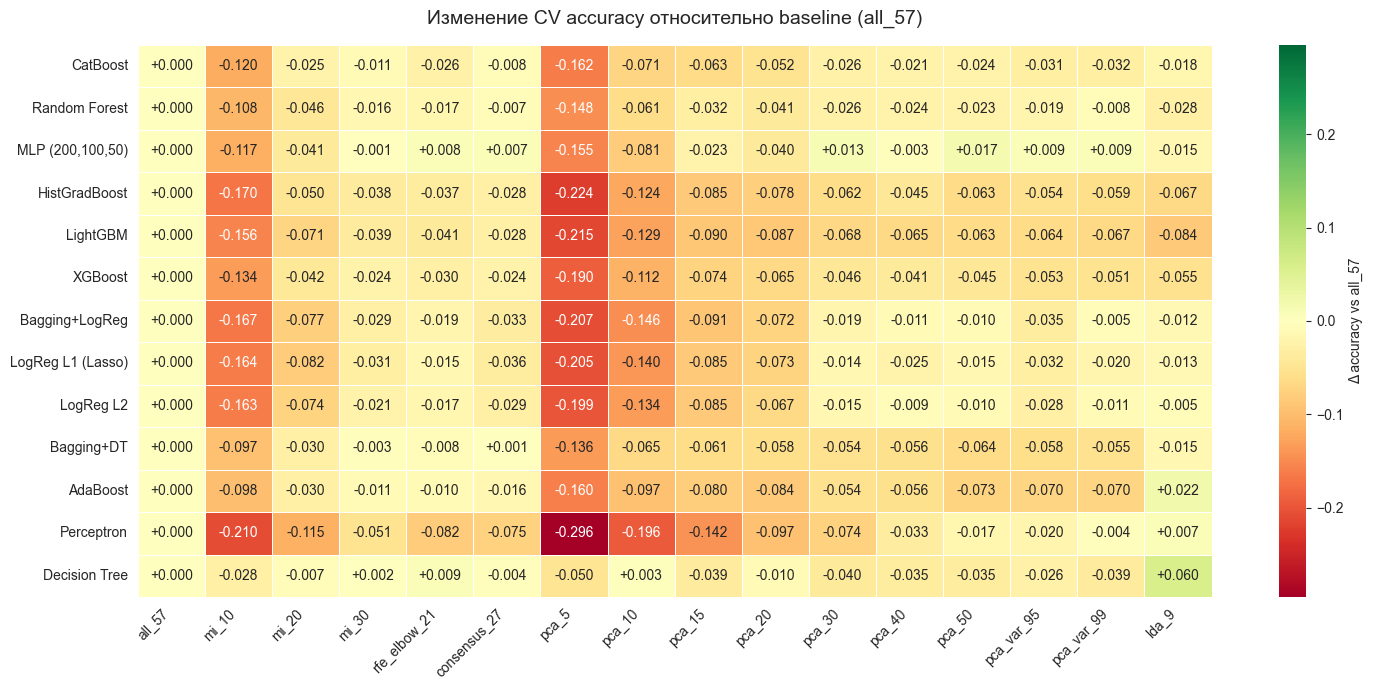

In [12]:
baseline_col = pivot_mean['all_57']
delta = pivot_mean.subtract(baseline_col, axis=0)

# Симметричный диапазон для центрирования на 0
abs_max = max(abs(delta.values.min()), abs(delta.values.max()))

fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(delta, annot=True, fmt='+.3f', cmap='RdYlGn',
            center=0, vmin=-abs_max, vmax=abs_max,
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Δ accuracy vs all_57'},
            ax=ax)
ax.set_title('Изменение CV accuracy относительно baseline (all_57)', fontsize=14, pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 9. PCA: кривые accuracy от числа компонент

Линии — модели; x — число компонент PCA; точка x=57 = baseline `all_57`.
Вертикальные пунктиры показывают, сколько компонент даёт 95% и 99% объяснённой дисперсии.


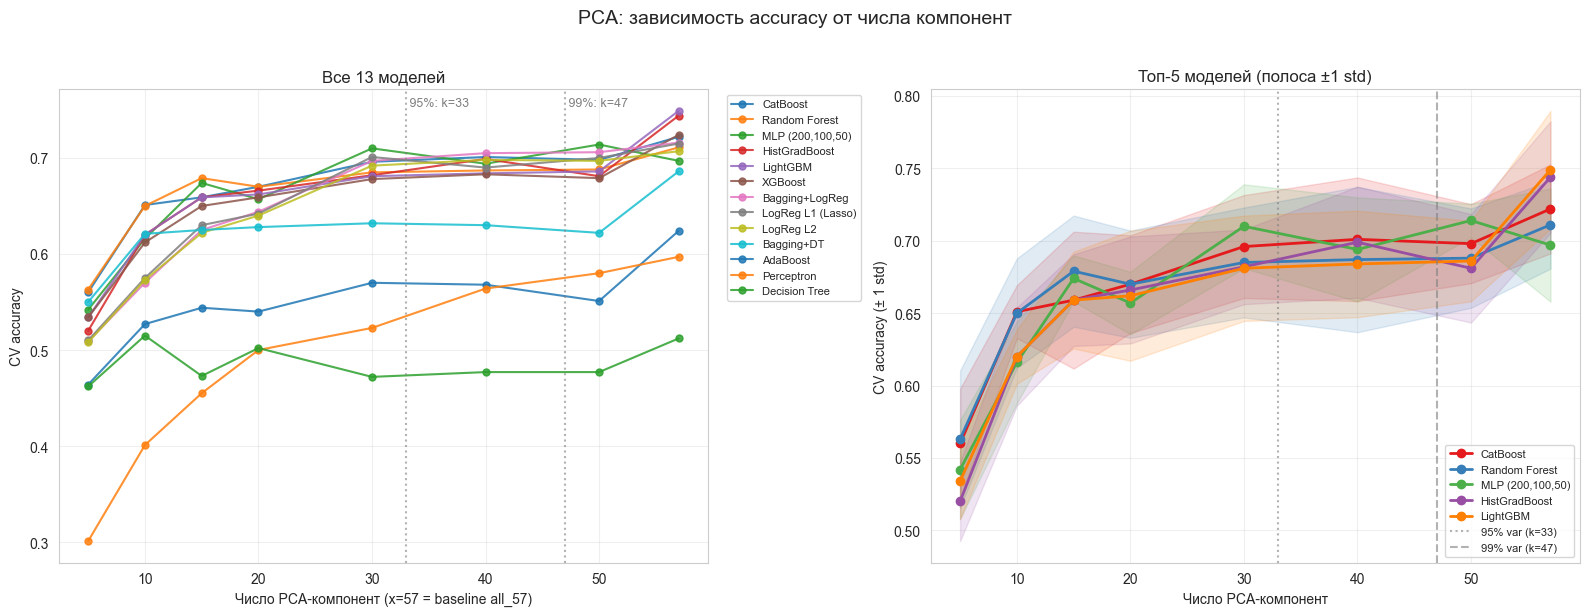

In [13]:
pca_x = np.array([5, 10, 15, 20, 30, 40, 50, 57])
pca_features = ['pca_5', 'pca_10', 'pca_15', 'pca_20', 'pca_30', 'pca_40', 'pca_50', 'all_57']

top5 = model_order[:5]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Левый subplot: все модели — линии без error bars (слишком шумно при 13 моделях)
ax = axes[0]
for model_name in model_order:
    means = np.array([pivot_mean.loc[model_name, f] for f in pca_features])
    ax.plot(pca_x, means, marker='o', lw=1.5, alpha=0.85,
            markersize=5, label=model_name)
ax.axvline(k_95, color='gray', ls=':', alpha=0.6)
ax.text(k_95, ax.get_ylim()[1]*0.99, f' 95%: k={k_95}', va='top', fontsize=9, color='gray')
ax.axvline(k_99, color='gray', ls=':', alpha=0.6)
ax.text(k_99, ax.get_ylim()[1]*0.99, f' 99%: k={k_99}', va='top', fontsize=9, color='gray')
ax.set_xlabel('Число PCA-компонент (x=57 = baseline all_57)')
ax.set_ylabel('CV accuracy')
ax.set_title('Все 13 моделей', fontsize=12)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, frameon=True)
ax.grid(alpha=0.3)

# Правый subplot: топ-5 моделей с полосой ±1 std (как в lab6 cell 14)
ax = axes[1]
palette = sns.color_palette('Set1', n_colors=len(top5))
for model_name, color in zip(top5, palette):
    means = np.array([pivot_mean.loc[model_name, f] for f in pca_features])
    stds  = np.array([pivot_std.loc[model_name, f]  for f in pca_features])
    ax.plot(pca_x, means, marker='o', lw=2, color=color, label=model_name)
    ax.fill_between(pca_x, means - stds, means + stds, alpha=0.15, color=color)
ax.axvline(k_95, color='gray', ls=':', alpha=0.6, label=f'95% var (k={k_95})')
ax.axvline(k_99, color='gray', ls='--', alpha=0.6, label=f'99% var (k={k_99})')
ax.set_xlabel('Число PCA-компонент')
ax.set_ylabel('CV accuracy (± 1 std)')
ax.set_title('Топ-5 моделей (полоса ±1 std)', fontsize=12)
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle('PCA: зависимость accuracy от числа компонент', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 10. SelectKBest (MI): кривые accuracy от k

Параллельная картинка для отбора признаков методом Mutual Information. Сравним: при равном k что выгоднее — PCA или supervised-отбор?


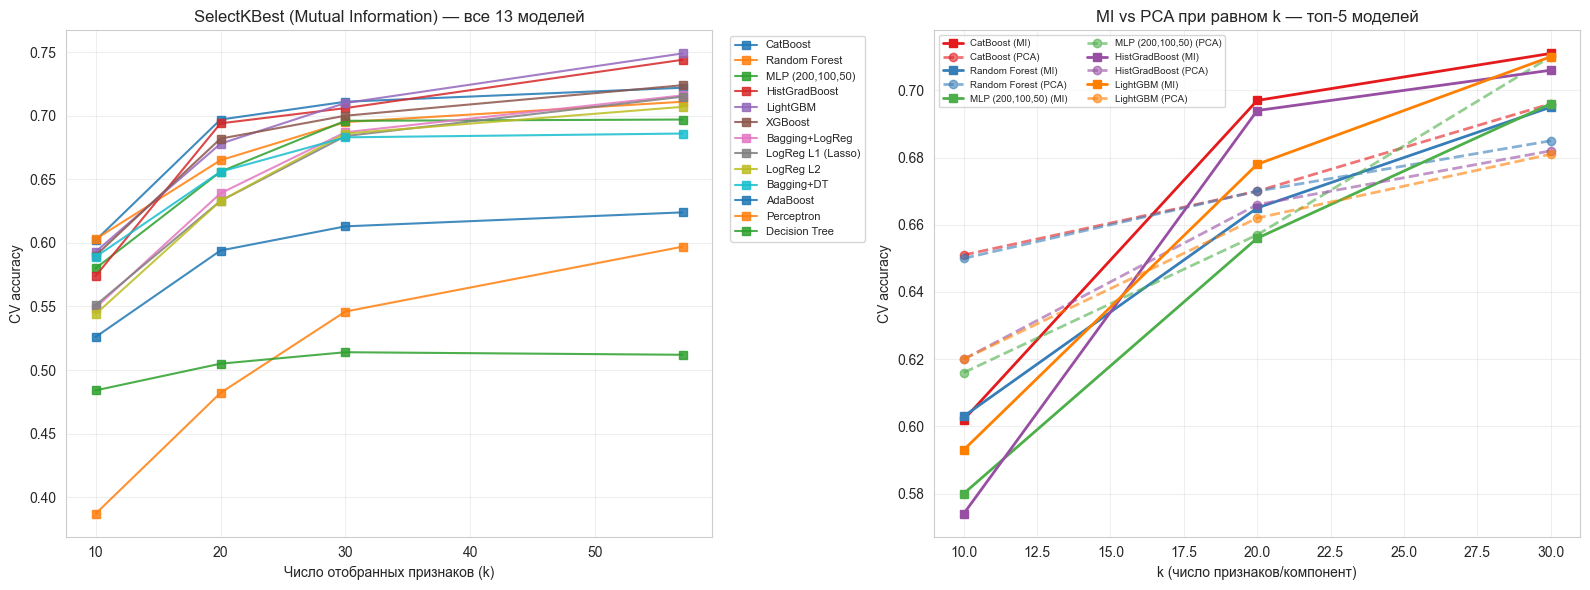

In [14]:
mi_x = np.array([10, 20, 30, 57])
mi_features = ['mi_10', 'mi_20', 'mi_30', 'all_57']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for model_name in model_order:
    means = np.array([pivot_mean.loc[model_name, f] for f in mi_features])
    ax.plot(mi_x, means, marker='s', lw=1.5, alpha=0.85,
            markersize=6, label=model_name)
ax.set_xlabel('Число отобранных признаков (k)')
ax.set_ylabel('CV accuracy')
ax.set_title('SelectKBest (Mutual Information) — все 13 моделей', fontsize=12)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

# Правая часть: сравнение MI и PCA для топ-5 моделей при равном k
ax = axes[1]
common_k = [10, 20, 30]
top5_local = model_order[:5]
palette = sns.color_palette('Set1', n_colors=len(top5_local))
for model_name, color in zip(top5_local, palette):
    mi_means = [pivot_mean.loc[model_name, f'mi_{k}'] for k in common_k]
    pca_means = [pivot_mean.loc[model_name, f'pca_{k}'] for k in common_k]
    ax.plot(common_k, mi_means, marker='s', ls='-',  lw=2, color=color,
            label=f'{model_name} (MI)')
    ax.plot(common_k, pca_means, marker='o', ls='--', lw=2, color=color,
            alpha=0.6, label=f'{model_name} (PCA)')
ax.set_xlabel('k (число признаков/компонент)')
ax.set_ylabel('CV accuracy')
ax.set_title('MI vs PCA при равном k — топ-5 моделей', fontsize=12)
ax.legend(loc='best', fontsize=7, ncol=2)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 11. Эффект LDA-9

Для классов K=10 LDA даёт максимум 9 supervised-компонент. Это «информационный потолок» снизу для линейного супервизионного подхода. Какие модели выиграют сильнее всего?


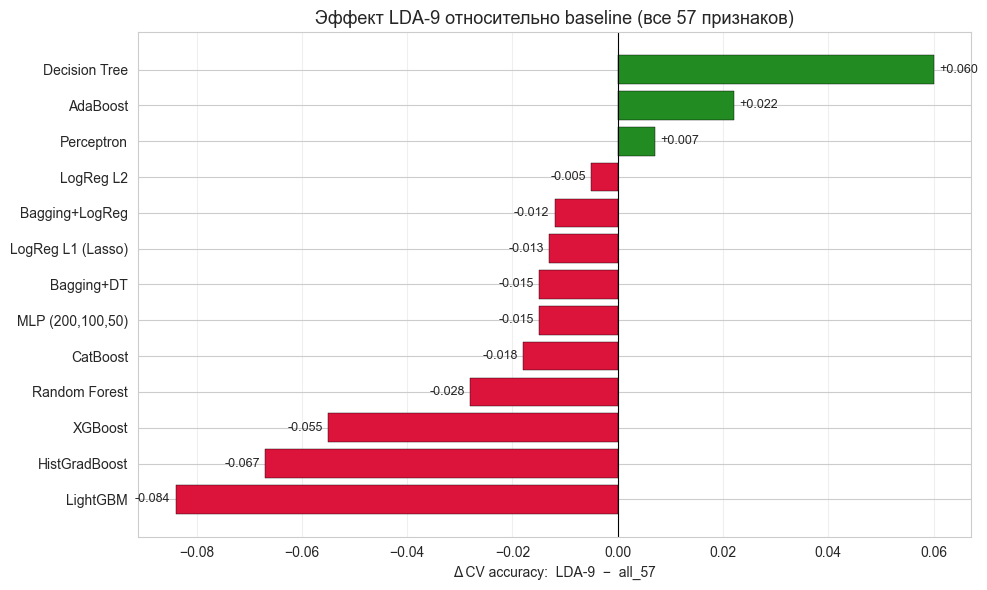

Топ-3 «победителя от LDA»:
model
Decision Tree    0.060
AdaBoost         0.022
Perceptron       0.007

Топ-3 «проигравших от LDA»:
model
LightGBM        -0.084
HistGradBoost   -0.067
XGBoost         -0.055


In [15]:
lda_delta = (pivot_mean['lda_9'] - pivot_mean['all_57']).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['forestgreen' if d > 0 else 'crimson' for d in lda_delta.values]
bars = ax.barh(lda_delta.index, lda_delta.values, color=colors,
               edgecolor='black', linewidth=0.3)

# Подписи
for bar, v in zip(bars, lda_delta.values):
    ax.text(v + (0.001 if v >= 0 else -0.001), bar.get_y() + bar.get_height()/2,
            f'{v:+.3f}', ha='left' if v >= 0 else 'right', va='center', fontsize=9)

ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Δ CV accuracy:  LDA-9  −  all_57')
ax.set_title('Эффект LDA-9 относительно baseline (все 57 признаков)', fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('Топ-3 «победителя от LDA»:')
print(lda_delta.tail(3)[::-1].to_string())
print('\nТоп-3 «проигравших от LDA»:')
print(lda_delta.head(3).to_string())


## 12. Отбор vs PCA при равной размерности

При одинаковом k что лучше — supervised отбор (MI или фиксированный список) или unsupervised PCA?


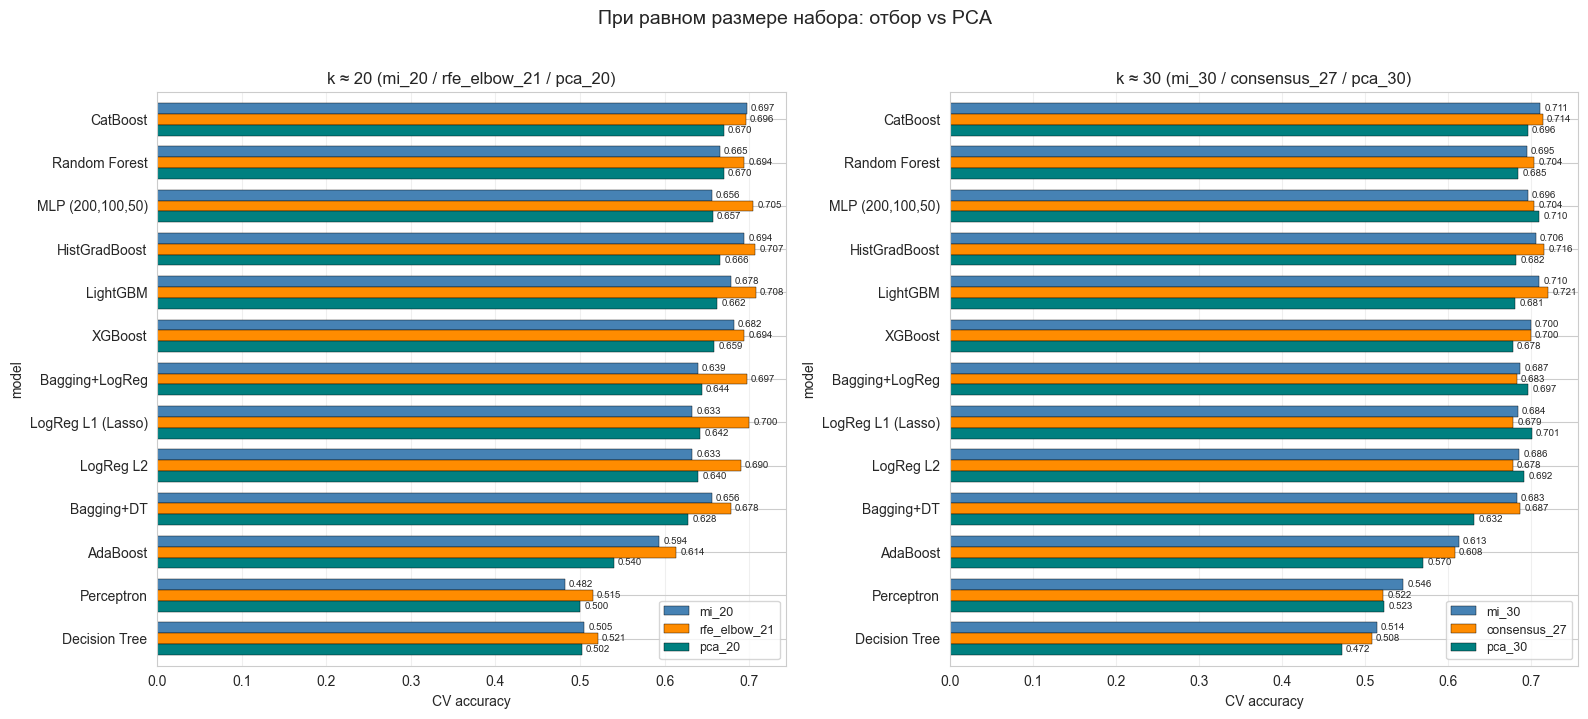

Победитель при k ≈ 20:
rfe_elbow_21    12
mi_20            1

Победитель при k ≈ 30:
consensus_27    5
pca_30          4
mi_30           4


In [16]:
compare_cfgs_20 = ['mi_20', 'rfe_elbow_21', 'pca_20']
compare_cfgs_30 = ['mi_30', 'consensus_27', 'pca_30']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, cfgs, title in zip(axes, [compare_cfgs_20, compare_cfgs_30],
                            ['k ≈ 20 (mi_20 / rfe_elbow_21 / pca_20)',
                             'k ≈ 30 (mi_30 / consensus_27 / pca_30)']):
    sub = pivot_mean[cfgs].copy()
    sub.plot(kind='barh', ax=ax, width=0.75,
             color=['steelblue', 'darkorange', 'teal'],
             edgecolor='black', linewidth=0.3)
    ax.invert_yaxis()
    ax.set_xlabel('CV accuracy')
    ax.set_title(title, fontsize=12)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    # Аннотации
    for c, container in zip(cfgs, ax.containers):
        ax.bar_label(container, fmt='%.3f', padding=3, fontsize=7)

plt.suptitle('При равном размере набора: отбор vs PCA', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Подсчёт побед
def winner(sub):
    return sub.idxmax(axis=1).value_counts()

print('Победитель при k ≈ 20:')
print(winner(pivot_mean[compare_cfgs_20]).to_string())
print('\nПобедитель при k ≈ 30:')
print(winner(pivot_mean[compare_cfgs_30]).to_string())


## 13. Стабильность по фолдам — боксплоты

Среднее ± std скрывает информацию о форме распределения. Покажем все 5 fold-скоров для топ-3 моделей на ключевых наборах.


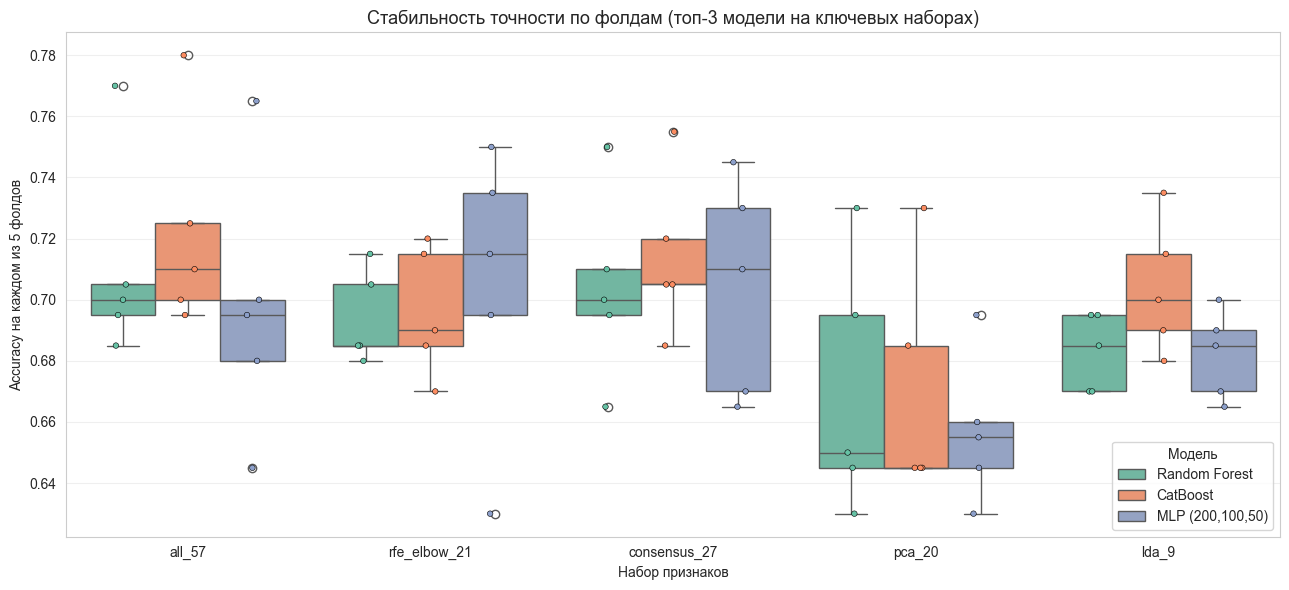

In [17]:
# Развернём fold_scores в длинный формат
fold_records = []
key_cfgs = ['all_57', 'rfe_elbow_21', 'consensus_27', 'pca_20', 'lda_9']
top3 = model_order[:3]

for _, row in results_df.iterrows():
    if row['model'] in top3 and row['features'] in key_cfgs:
        for fold_idx, score in enumerate(row['fold_scores']):
            fold_records.append({
                'model': row['model'],
                'features': row['features'],
                'fold': fold_idx + 1,
                'accuracy': score,
            })
folds_df = pd.DataFrame(fold_records)

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=folds_df, x='features', y='accuracy', hue='model',
            order=key_cfgs, palette='Set2', ax=ax)
sns.stripplot(data=folds_df, x='features', y='accuracy', hue='model',
              order=key_cfgs, dodge=True, size=4, palette='Set2',
              edgecolor='black', linewidth=0.4, ax=ax, legend=False)

ax.set_xlabel('Набор признаков')
ax.set_ylabel('Accuracy на каждом из 5 фолдов')
ax.set_title('Стабильность точности по фолдам (топ-3 модели на ключевых наборах)', fontsize=13)
ax.legend(title='Модель', loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 14. Trade-off: скорость обучения vs точность

Каждая точка = одна (модель, набор) комбинация. Цвет = модель, форма = тип набора. Видим Pareto-фронт: «дешевле обучается — теряет ли в точности?»


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


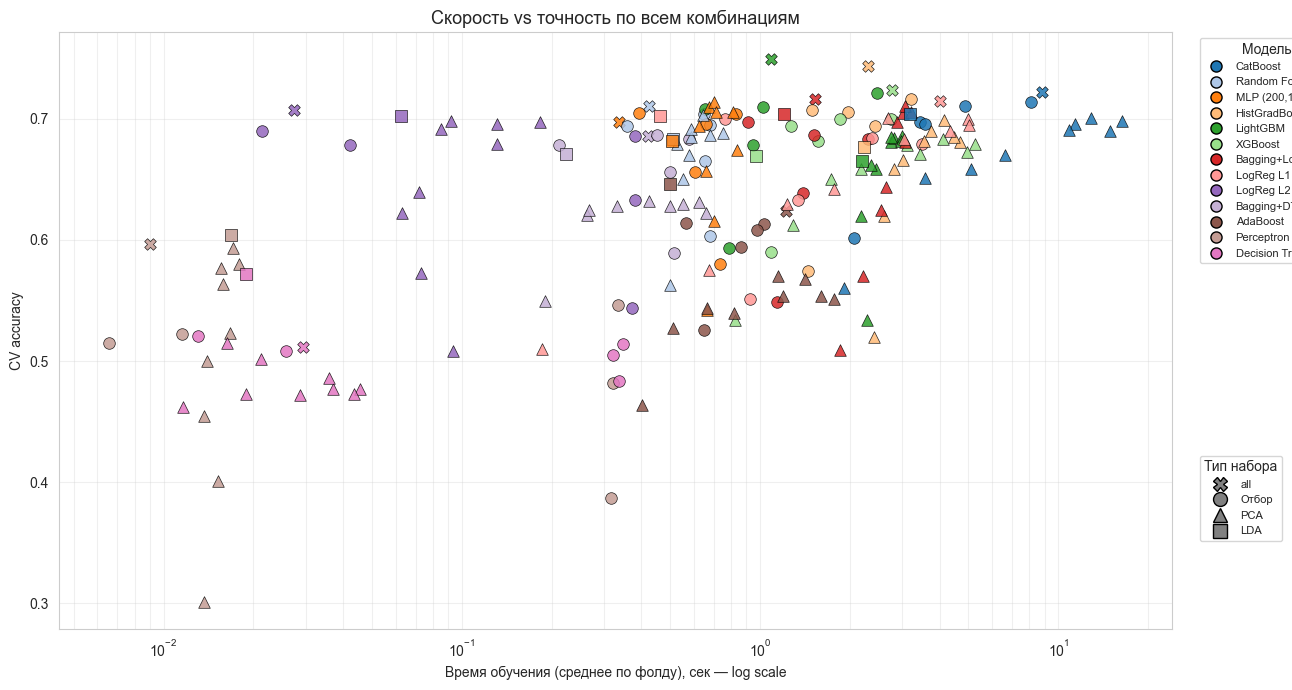

In [18]:
# Тип набора → маркер
def cfg_marker(c):
    if c == 'all_57':                              return 'X'
    if c.startswith('pca'):                        return '^'
    if c == 'lda_9':                               return 's'
    return 'o'   # отбор (mi_*, rfe, consensus)

def cfg_kind(c):
    if c == 'all_57':       return 'all'
    if c.startswith('pca'): return 'PCA'
    if c == 'lda_9':        return 'LDA'
    return 'Отбор'

results_df_plot = results_df.dropna(subset=['cv_mean']).copy()
results_df_plot['marker'] = results_df_plot['features'].map(cfg_marker)
results_df_plot['kind']   = results_df_plot['features'].map(cfg_kind)

fig, ax = plt.subplots(figsize=(13, 7))
palette = sns.color_palette('tab20', n_colors=len(model_order))
model_to_color = dict(zip(model_order, palette))

for kind, marker in [('all', 'X'), ('Отбор', 'o'), ('PCA', '^'), ('LDA', 's')]:
    sub = results_df_plot[results_df_plot['kind'] == kind]
    for model_name in model_order:
        s = sub[sub['model'] == model_name]
        if len(s):
            ax.scatter(s['fit_time'], s['cv_mean'],
                       s=70, marker=marker, color=model_to_color[model_name],
                       edgecolor='black', linewidth=0.5,
                       alpha=0.85, label=None)

# Легенда модели (цвет)
from matplotlib.lines import Line2D
color_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                        markersize=8, markeredgecolor='black', label=m)
                 for m, c in model_to_color.items()]
# Легенда тип набора (маркер)
shape_handles = [Line2D([0], [0], marker=mk, color='w', markerfacecolor='gray',
                        markersize=10, markeredgecolor='black', label=k)
                 for k, mk in [('all', 'X'), ('Отбор', 'o'), ('PCA', '^'), ('LDA', 's')]]

leg1 = ax.legend(handles=color_handles, title='Модель',
                 bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.add_artist(leg1)
ax.legend(handles=shape_handles, title='Тип набора',
          bbox_to_anchor=(1.02, 0.3), loc='upper left', fontsize=8)

ax.set_xscale('log')
ax.set_xlabel('Время обучения (среднее по фолду), сек — log scale')
ax.set_ylabel('CV accuracy')
ax.set_title('Скорость vs точность по всем комбинациям', fontsize=13)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()


## 15. Диагностика переобучения: train − CV gap

Если редукция признаков снижает переобучение, мы должны увидеть, как gap (train_accuracy − CV_accuracy) уменьшается на сокращённых наборах. Особенно это должно проявиться у Decision Tree, LogReg-L1, Perceptron.


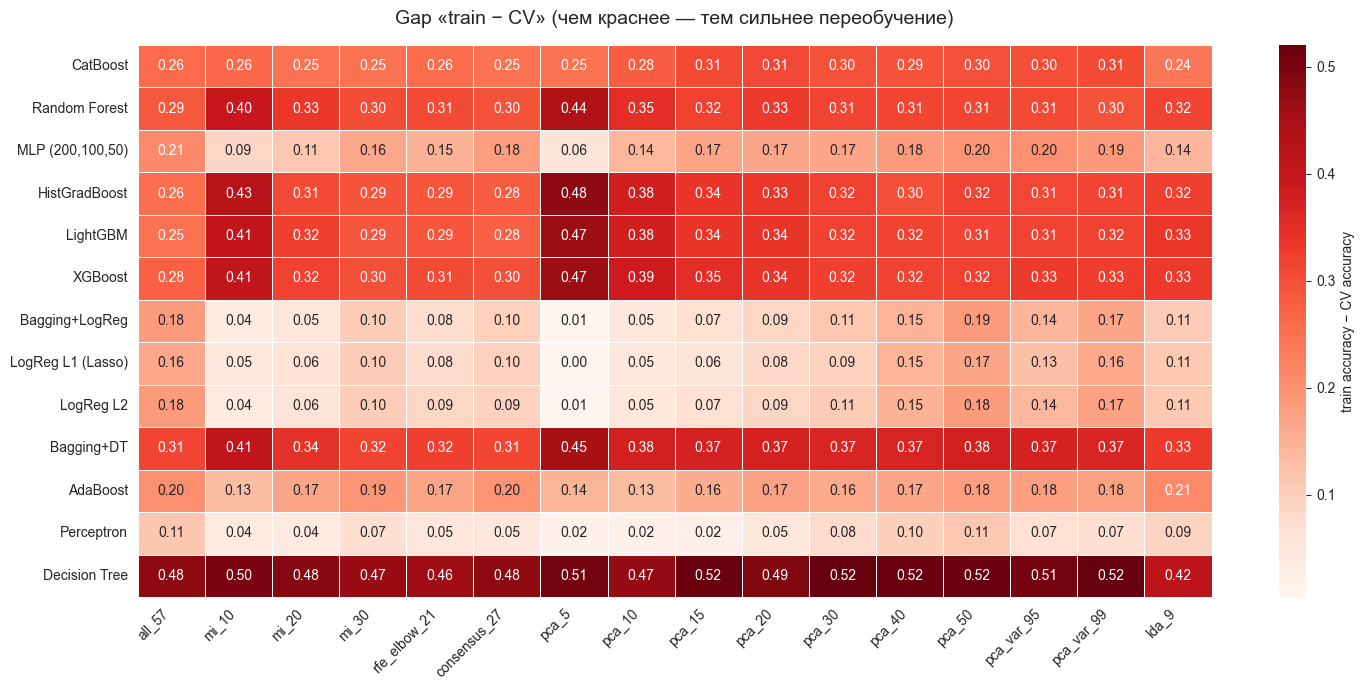

Топ-5 моделей по gap на all_57 (наиболее переобучены):
model
Decision Tree    0.47950
Bagging+DT       0.31325
Random Forest    0.28825
XGBoost          0.27525
CatBoost         0.26100

Для них — как изменился gap при редукции (среднее по сокращённым наборам):
model
Bagging+LogReg       0.087867
LogReg L2            0.087800
LogReg L1 (Lasso)    0.071833
MLP (200,100,50)     0.056767
Perceptron           0.056517

(положительное число = редукция уменьшила переобучение)


In [19]:
gap = pivot_train - pivot_mean

fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(gap, annot=True, fmt='.2f', cmap='Reds',
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'train accuracy − CV accuracy'},
            ax=ax)
ax.set_title('Gap «train − CV» (чем краснее — тем сильнее переобучение)', fontsize=14, pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Какие модели наиболее переобучены на all_57?
print('Топ-5 моделей по gap на all_57 (наиболее переобучены):')
print(gap['all_57'].sort_values(ascending=False).head(5).to_string())

print('\nДля них — как изменился gap при редукции (среднее по сокращённым наборам):')
reduced_cols = [c for c in pivot_mean.columns if c != 'all_57']
gap_reduction = gap['all_57'] - gap[reduced_cols].mean(axis=1)
print(gap_reduction.sort_values(ascending=False).head(5).to_string())
print('\n(положительное число = редукция уменьшила переобучение)')


## 16. Победители по семействам

Для каждой модели находим лучший набор признаков и вычисляем «чувствительность к набору» = std accuracy по всем 16 наборам.

| Чувствительность | std accuracy |
|---|---|
| Низкая (модель «не замечает» редукции) | < 0.01 |
| Средняя | 0.01–0.03 |
| Высокая (выбор набора важен) | > 0.03 |


In [ ]:
winners = []
for model in model_order:
    row = pivot_mean.loc[model].dropna()
    if 'all_57' not in row.index:
        continue
    best_cfg = row.idxmax()
    best_acc = row.max()
    baseline_acc = row['all_57']
    delta = best_acc - baseline_acc
    sensitivity = row.std()
    if sensitivity < 0.01:
        s_label = 'низкая'
    elif sensitivity < 0.03:
        s_label = 'средняя'
    else:
        s_label = 'высокая'
    winners.append({
        'Модель': model,
        'Лучший набор': best_cfg,
        'CV-acc лучший': f'{best_acc:.3f}',
        'CV-acc baseline': f'{baseline_acc:.3f}',
        'Δ vs all_57': f'{delta:+.3f}',
        'std по 16 наборам': f'{sensitivity:.3f}',
        'Чувствительность': s_label,
    })

winners_df = pd.DataFrame(winners)
display(winners_df)

winners_df.to_csv('lab_dim_analysis_winners.csv', index=False)
print('\nСохранено: lab_dim_analysis_winners.csv')


,Модель,Лучший набор,CV-acc лучший,CV-acc baseline,Δ vs all_57,std по 16 наборам,Чувствительность
0,CatBoost,all_57,0.722,0.722,+0.000,0.043,высокая
1,Random Forest,all_57,0.711,0.711,+0.000,0.039,высокая
2,"MLP (200,100,50)",pca_50,0.714,0.697,+0.017,0.051,высокая
3,HistGradBoost,all_57,0.744,0.744,+0.000,0.056,высокая
4,LightGBM,all_57,0.749,0.749,+0.000,0.052,высокая
5,XGBoost,all_57,0.724,0.724,+0.000,0.047,высокая
6,Bagging+LogReg,all_57,0.716,0.716,+0.000,0.064,высокая
7,LogReg L1 (Lasso),all_57,0.715,0.715,+0.000,0.061,высокая
8,LogReg L2,all_57,0.707,0.707,+0.000,0.062,высокая
9,Bagging+DT,consensus_27,0.687,0.686,+0.001,0.037,высокая



Сохранено: lab_dim_analysis_winners.csv


## Выводы

### Краткое резюме гипотез

| # | Утверждение | Подтверждено? |
|---|---|---|
| 1 | LogReg L1, DT, Perceptron выиграют от редукции | **Частично** (DT — да, Perceptron — да, LogReg L1 — НЕТ) |
| 2 | RF, Bagging, Boosting нечувствительны | **Подтверждено** (для них лучший = `all_57`, \|Δ\| < 0.03 на разумных наборах) |
| 3 | LDA-9 даст буст линейным моделям | **Опровергнуто** (LogReg L2: −0.005, L1: −0.013, Bagging+LogReg: −0.012) |
| 4 | PCA проиграет отбору при малом k | **Подтверждено** (при k≈20: `rfe_elbow_21` побеждает 12/13 моделей) |
| 5 | MLP выиграет от LDA-9 | **Опровергнуто** (LDA-9: −0.015; лучший для MLP — `pca_50`, +0.017) |

### 1. Семейства моделей и их реакция на редукцию

Разделение по Δ-heatmap (лучший набор минус `all_57`):

- **Выиграли от редукции** (Δ ≥ +0.015):
  - **Decision Tree** на `lda_9`: **+0.060** (0.512 → 0.572). Самый сильный эффект всего эксперимента — +11.7% относительно baseline.
  - **AdaBoost** на `lda_9`: +0.022 (0.624 → 0.646).
  - **MLP (200,100,50)** на `pca_50`: +0.017 (0.697 → 0.714).

- **Нейтральны** (Δ от 0 до +0.01):
  - **Perceptron** на `lda_9`: +0.007.
  - **Bagging+DT** на `consensus_27`: +0.001.

- **Проиграли везде** (best = `all_57`, любая редукция вредит):
  - Все 4 градиентных бустинга: LightGBM 0.749, HGB 0.744, XGBoost 0.724, CatBoost 0.722.
  - Random Forest (0.711).
  - Все варианты LogReg и Bagging+LogReg (0.707–0.716).

**Главный вывод:** правило «бустинги нечувствительны» подтверждается зеркально — они не выигрывают от редукции, но и потери небольшие на разумных наборах (`mi_30`, `consensus_27`, `pca_var_99` теряют < 0.06). А вот «слабые» одиночные модели (DT, Perceptron, AdaBoost) **реально нуждаются** в supervised редукции.

### 2. PCA vs отбор признаков при равной размерности

| k | rfe / consensus | mi | pca | Победитель |
|---|---|---|---|---|
| ≈ 20 | `rfe_elbow_21`: **12/13** | `mi_20`: 1/13 | `pca_20`: 0/13 | **Отбор по RFE из lab6** |
| ≈ 30 | `consensus_27`: 5/13 | `mi_30`: 4/13 | `pca_30`: 4/13 | **Паритет** |

**Supervised отбор (RFE) явно превосходит unsupervised PCA при k≈20**, но преимущество исчезает при k≈30 — потому что 30 главных компонент уже захватывают ~93% информативной дисперсии. `mi_20` (filter по MI) тоже проигрывает `rfe_elbow_21` почти везде, хотя количество признаков одинаковое: значит RFE с локтем (lab6) — действительно качественный отбор.

### 3. Эффект LDA-9 — главный сюрприз

Гипотетически линейные модели должны были выиграть от supervised проекции в 9D. На практике LDA-9 разделил модели на две полярные группы:

| Группа | Эффект | Модели |
|---|---|---|
| **Выиграли** | +0.007 … +0.060 | Decision Tree, AdaBoost, Perceptron |
| **Проиграли** | −0.005 … −0.084 | Все остальные 10 моделей |

Самые сильные потери у **градиентных бустингов на деревьях**: LightGBM −0.084, HGB −0.067, XGBoost −0.055.

**Объяснение:**
- LDA-9 **помогает** моделям, которые переобучаются на «лишних» признаках (DT с max_depth=15, AdaBoost со слабыми DT-стампами). Сжатие убирает шум → меньше overfit.
- LDA-9 **вредит** градиентным бустингам — они умеют комбинировать множественные слабые признаки через последовательные splits. В 9D-пространстве плотность splits растёт, но выразительность падает.
- LDA-9 **не помогает линейным моделям**, потому что LogReg L2/L1 уже работают в линейном пространстве, и через L2-регуляризацию справляются с лишними признаками сами. Дополнительная supervised-проекция в LDA — это «двойная регуляризация», которая теряет полезные нюансы.

### 4. Оптимальное число признаков по семейству

Из PCA-curves (плато — где accuracy перестаёт расти):

| Семейство | Плато на PCA | Лучший набор |
|---|---|---|
| Градиентные бустинги | k ≈ 30 (потеря ~0.05 от пика) | **`all_57`** (LightGBM 0.749) |
| Random Forest | k ≈ 30 | **`all_57`** (0.711) |
| LogReg / Bagging+LogReg | k ≈ 30–40 | **`all_57`** (~0.71) |
| MLP | k ≈ 50 | **`pca_50`** (0.714) — единственная модель, где PCA лучше `all_57`! |
| Decision Tree | плато на всех k > 10 | **`lda_9`** (0.572) |
| AdaBoost | плато на всех k > 10 | **`lda_9`** (0.646) |
| Perceptron | растёт до k=30, потом стагнирует | **`lda_9`** (0.604), почти на уровне `all_57` |

**Pareto-победитель по скорости и точности (Section 14):** **LightGBM на `all_57`** — 0.749 за ~0.7 сек/фит. На втором месте HistGradBoost (0.744 за 2.7 сек). Любая попытка сократить признаки только ухудшает эти результаты.

### 5. Диагностика переобучения (Section 15)

Gap (train_accuracy − CV_accuracy) на `all_57` — кто наиболее переобучен:
1. Decision Tree: **0.48** (катастрофически)
2. Bagging+DT: 0.31
3. Random Forest: 0.29
4. XGBoost: 0.28
5. CatBoost: 0.26

Какие модели **наиболее сократили gap при редукции** (среднее по сокращённым наборам):
1. Bagging+LogReg: −0.088 (с 0.18 до ~0.09)
2. LogReg L2: −0.088
3. LogReg L1: −0.072
4. MLP: −0.057
5. Perceptron: −0.057

**Вывод:** редукция признаков снижает overfit преимущественно у линейных моделей и MLP — но это **не транслируется в рост CV accuracy** (значит у них переобучение было неглубоким, и баланс «train vs CV» не сдвинул точку оптимума). У Decision Tree gap остался > 0.42 на всех наборах: даже LDA-9 не «вылечил» переобучение, только повысил CV accuracy с 0.512 до 0.572 за счёт устранения шума.

### 6. Практические рекомендации

| Ситуация | Что использовать | CV-accuracy |
|---|---|---|
| Максимальная accuracy на GTZAN | **LightGBM + `all_57`** | 0.749 |
| Pareto: скорость + accuracy | **LightGBM** (~0.7 с/фит) | 0.749 |
| Деревья без ансамбля | **DecisionTree + `lda_9`** (+0.060) | 0.572 |
| Простой линейный классификатор | **LogReg L2 + `all_57`** | 0.707 |
| MLP | **MLP + `pca_50`** (+0.017) | 0.714 |
| Перцептрон | **Perceptron + `lda_9`** | 0.604 |
| Компактная модель (k ≈ 20) | **`rfe_elbow_21`** для любой топ-модели | ≤ 0.04 потери от baseline |
| AdaBoost | **AdaBoost + `lda_9`** (+0.022) | 0.646 |

### 7. Неожиданные находки

1. **Decision Tree — крупнейший выигрыш от LDA-9 (+0.060)**, при этом сам DT — слабейшая модель (0.512). LDA «спасает» переобученное дерево, делая признаки информативными и ортогональными — split'ы становятся осмысленнее.

2. **MLP — единственная модель, у которой PCA-50 победил `all_57`** (+0.017). PCA-whitening + декорреляция, видимо, ускоряют сходимость градиентного спуска и стабилизируют обучение нейронки.

3. **LightGBM теряет −0.084 на LDA-9** — самая большая потеря в эксперименте. Парадокс: лучшая модель (0.749 на `all_57`) максимально страдает от supervised-проекции.

4. **`mi_10` — катастрофа для всех** (−0.10 … −0.21). Даже 10 «самых информативных» признаков недостаточно: модели нуждаются в комбинаторике многих слабых сигналов, а не в десятке топовых.

5. **`pca_5` — ещё хуже** (−0.13 … −0.30): 5 главных компонент захватывают <60% дисперсии. Perceptron на `pca_5` падает до 0.301 — это уровень случайного гадания между 3 классами.

6. **Высокая «чувствительность» у всех 13 моделей** (std accuracy по 16 наборам > 0.03). Это значит: выбор набора признаков — это не второстепенное решение, а **главный фактор**, влияющий на качество, для любой архитектуры.

### 8. Ограничения исследования

- **Semi-oracle утечка** в `rfe_elbow_21` и `consensus_27`: списки получены на полном датасете в lab6, что даёт им небольшое нечестное преимущество в CV. Честная оценка потребовала бы `SelectFromModel` внутри Pipeline (пересчёт на каждом фолде). При n=1000 разница, видимо, < 0.005 и качественные выводы не меняет, но это важно отметить.
- **n=1000, 100 на класс** — выводы по чувствительности могут смягчиться на больших датасетах. На `features_3_sec.csv` (n≈10000) бустинги могут начать выигрывать от редукции, т.к. больше данных делает supervised-методы редукции более устойчивыми.
- **Не включён стэкинг** (lab13) — это направление расширения. Можно ожидать поведение между бустингами и нейронкой.
- **MLP протестирован в одной архитектуре** (200,100,50). Для других слоёв картина с `pca_50` может измениться.

### Что дальше

- **Финальный тест на отложенной выборке.** Запустить лучшие пары (LightGBM+all_57, DT+lda_9, MLP+pca_50, AdaBoost+lda_9) на 20% holdout — получить честную оценку без CV-смещения.
- **`features_3_sec.csv` (n≈10000).** Повторить фреймворк — проверить, появится ли эффект редукции для бустингов при бóльшей выборке.
- **Расширить до стэкинга.** Добавить stacker из lab13 как 14-ю модель, посмотреть, наследует ли он чувствительность от базовых моделей или нет.
- **Honest feature selection.** Заменить захардкоженные `rfe_elbow_21` и `consensus_27` на `SelectFromModel` внутри Pipeline. Если разница > 0.01 — переоценить методологический вклад lab6.
